In [49]:
import yfinance as yf

# Fetch stock price for Celltrion for recent 10 days
celltrion = yf.Ticker("068270.KS")
celltrion_data = celltrion.history(period="10d")
celltrion_data["Name"] = "Celltrion"
# Fetch Gold price for recent 10 days
gold = yf.Ticker("GC=F")
gold_data = gold.history(period="10d")
gold_data["Name"] = "Gold"
# Fetch Nasdaq index price for recent 10 days
nasdaq = yf.Ticker("^IXIC")
nasdaq_data = nasdaq.history(period="10d")
nasdaq_data["Name"] = "Nasdaq"
# Fetch S&P 500 index price for recent 10 days
sp500 = yf.Ticker("^GSPC")
sp500_data = sp500.history(period="10d")
sp500_data["Name"] = "S&P 500"
# Fetch Bitcoin price for recent 10 days
bitcoin = yf.Ticker("BTC-USD")
bitcoin_data = bitcoin.history(period="10d")
bitcoin_data["Name"] = "Bitcoin"
# Fetch bond price for recent 10 days
bond = yf.Ticker("^TNX")
bond_data = bond.history(period="10d")
bond_data["Name"] = "Bond"
# Fetch some other financial indicator, for example VIX index (expected volatility index)
vix = yf.Ticker("^VIX")
vix_data = vix.history(period="10d")
vix_data["Name"] = "VIX"

import matplotlib.pyplot as plt

In [51]:
# print(celltrion_data)
print(gold_data)
# print(nasdaq_data)
# print(sp500_data)
# print(bitcoin_data)
# print(bond_data)
# print(vix_data)

                                  Open         High          Low        Close  \
Date                                                                            
2025-09-29 00:00:00-04:00  3754.800049  3827.600098  3754.800049  3820.899902   
2025-09-30 00:00:00-04:00  3827.500000  3865.500000  3793.399902  3840.800049   
2025-10-01 00:00:00-04:00  3863.500000  3891.899902  3853.300049  3867.500000   
2025-10-02 00:00:00-04:00  3856.199951  3888.600098  3823.699951  3839.699951   
2025-10-03 00:00:00-04:00  3855.199951  3886.800049  3853.699951  3880.800049   
2025-10-06 00:00:00-04:00  3931.300049  3960.000000  3926.800049  3948.500000   
2025-10-07 00:00:00-04:00  3959.399902  3981.500000  3940.000000  3976.600098   
2025-10-08 00:00:00-04:00  4061.800049  4064.600098  4019.199951  4045.000000   

                           Volume  Dividends  Stock Splits  Name  
Date                                                              
2025-09-29 00:00:00-04:00    8860        0.0           

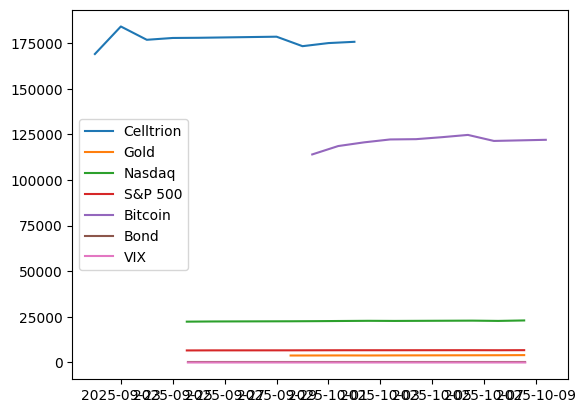

In [3]:
plt.plot(celltrion_data["Close"], label="Celltrion")
plt.plot(gold_data["Close"], label="Gold")
plt.plot(nasdaq_data["Close"], label="Nasdaq")
plt.plot(sp500_data["Close"], label="S&P 500")
plt.plot(bitcoin_data["Close"], label="Bitcoin")
plt.plot(bond_data["Close"], label="Bond")
plt.plot(vix_data["Close"], label="VIX")
plt.legend()
plt.show()


In [ ]:
# Normalize the data
celltrion_data["Close"] = celltrion_data["Close"] / celltrion_data["Close"].iloc[0]
gold_data["Close"] = gold_data["Close"] / gold_data["Close"].iloc[0]
nasdaq_data["Close"] = nasdaq_data["Close"] / nasdaq_data["Close"].iloc[0]
sp500_data["Close"] = sp500_data["Close"] / sp500_data["Close"].iloc[0]
bitcoin_data["Close"] = bitcoin_data["Close"] / bitcoin_data["Close"].iloc[0]
bond_data["Close"] = bond_data["Close"] / bond_data["Close"].iloc[0]
vix_data["Close"] = vix_data["Close"] / vix_data["Close"].iloc[0]

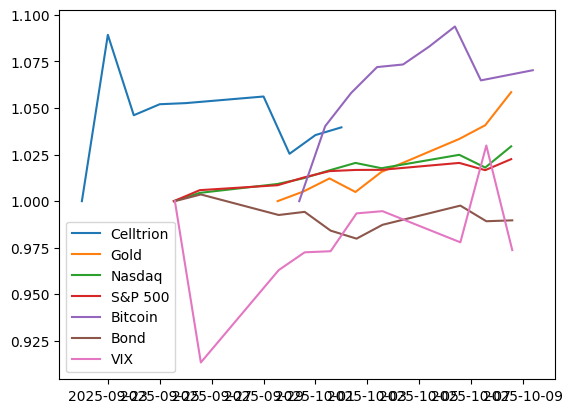

In [5]:
# Visualize on a single chart using matplotlib
plt.plot(celltrion_data["Close"], label="Celltrion")
plt.plot(gold_data["Close"], label="Gold")
plt.plot(nasdaq_data["Close"], label="Nasdaq")
plt.plot(sp500_data["Close"], label="S&P 500")
plt.plot(bitcoin_data["Close"], label="Bitcoin")
plt.plot(bond_data["Close"], label="Bond")
plt.plot(vix_data["Close"], label="VIX")
plt.legend()
plt.show()

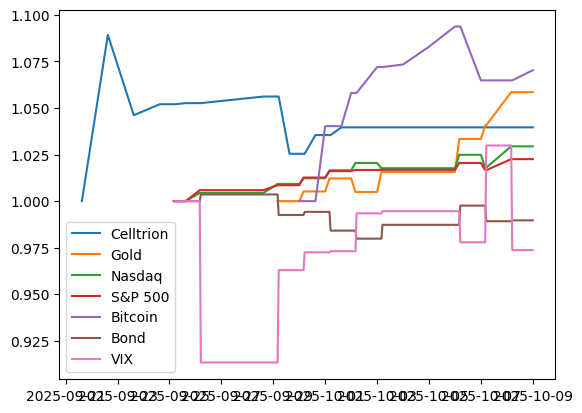

In [9]:
# pre-process the data for empty dates (fill it with previous day's data)

common_dates = celltrion_data.index.union(gold_data.index).union(nasdaq_data.index).union(sp500_data.index).union(bitcoin_data.index).union(bond_data.index).union(vix_data.index)

celltrion_data = celltrion_data.reindex(common_dates).ffill()
gold_data = gold_data.reindex(common_dates).ffill()
nasdaq_data = nasdaq_data.reindex(common_dates).ffill()
sp500_data = sp500_data.reindex(common_dates).ffill()
bitcoin_data = bitcoin_data.reindex(common_dates).ffill()
bond_data = bond_data.reindex(common_dates).ffill()
vix_data = vix_data.reindex(common_dates).ffill()

#Then Visualize again
plt.plot(celltrion_data["Close"], label="Celltrion")
plt.plot(gold_data["Close"], label="Gold")
plt.plot(nasdaq_data["Close"], label="Nasdaq")
plt.plot(sp500_data["Close"], label="S&P 500")
plt.plot(bitcoin_data["Close"], label="Bitcoin")
plt.plot(bond_data["Close"], label="Bond")
plt.plot(vix_data["Close"], label="VIX")
plt.legend()
plt.show()

In [70]:
# A full pipeline for preprocessing data that come in an array of dataframes
import pandas as pd

def preprocess_data(dataframes: list[pd.DataFrame]) -> list[pd.DataFrame]:
    # First, forward-fill the data in each DataFrame to fill in any missing values
    processed = []
    for df in dataframes:
        df_filled = df.ffill()  # Forward fill missing values within each dataframe
        processed.append(df_filled)
    
    # Now, find the union of all dates across all dataframes
    common_dates = processed[0].index
    for df in processed[1:]:
        common_dates = common_dates.union(df.index)
    
    # Reindex all dataframes to the common set of dates and apply forward-fill again
    final_processed = []
    for df in processed:
        df_new = df.reindex(common_dates).ffill()  # Reindex and ffill missing dates
        # Normalize the 'Close' column
        # Normalize 'Close' by dividing by the first non-null, non-zero value
        valid_close = df_new["Close"].dropna()
        nonzero_close = valid_close[valid_close.ne(0)]
        first_nonzero = nonzero_close.iloc[0] if not nonzero_close.empty else 1.0
        df_new["Close"] = df_new["Close"] / first_nonzero
        final_processed.append(df_new)
    
    return final_processed

In [71]:
#Run with new function

dfs = preprocess_data([celltrion_data, gold_data, nasdaq_data, sp500_data, bitcoin_data, bond_data, vix_data])

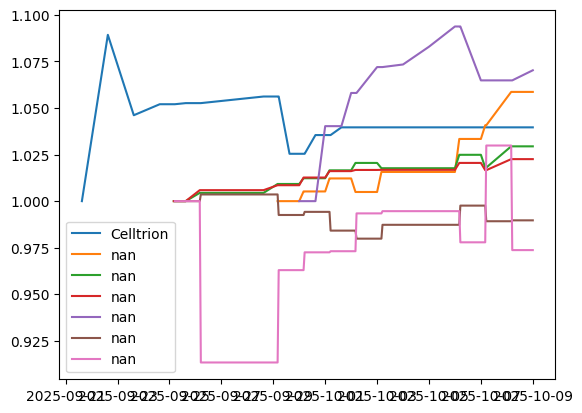

In [72]:
#then visualize
for df in dfs:
    plt.plot(df["Close"], label=df["Name"].iloc[0])
plt.legend()
plt.show()